In [1]:
library(edgeR)
library(RUVSeq)
library(tximport)
library(EDASeq)
library(tidyverse)
library(ggplot2)

Loading required package: limma

Loading required package: Biobase

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:limma’:

    plotMA


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Welcome to Bioconductor

    Vignettes contain introductory material; view with
    'browseVignettes()'. To cite Bioconductor, see
    'citation("Biobase")', and for packages 'citation("pkgname")'.


Loading required package: EDASeq

Loading req

In [ ]:
data<-read.delim("/counts_sQC_gAll_nRaw.tsv")
metadata<-read.delim("/sample_meta_passQC.tsv")
sample_ids <- metadata$sample_id   # replace with the correct column name if different
data_sub <- data[, colnames(data) %in% sample_ids]
dge <- DGEList(counts = data_sub)
dge <- calcNormFactors(dge, method = "TMM")
norm_exprData <- cpm(dge, log = TRUE)  # Log-transformed normalized counts (log2NX)
markers<-read.delim("/PanglaoDB_markers_27_Mar_2020.tsv")
key<-read.delim("/gencode.biotype.name.key.tsv")



In [3]:

colnames(markers) <- gsub("[^A-Za-z0-9]", "_", colnames(markers))
platelet<-markers%>%filter(cell_type=="Platelets")
platelet <- platelet %>% rename(gene_name = official_gene_symbol)
gene_ids <- platelet %>%
  left_join(key, by = "gene_name") %>%
  pull(gene_id) %>%
  na.omit() %>%           # Remove missing mappings
  unique() %>%            # Remove duplicates
  as.character()          # Ensure it's a character vector

In [4]:
length(gene_ids)

[1] 127

In [5]:

# platelet_marker_genes <- c((gene_ids_string))#top200 %>% pull(gene_id)#c("ENSG00000240361.2", "ENSG00000186092.7", "ENSG00000223972.5", "ENSG00000227232.5") 
common_genes <- intersect(gene_ids, rownames(norm_exprData))
print(length(common_genes))  # Should return the number of common genes
print(common_genes)  # Print the common genes
if (length(common_genes) > 0) {
  # Use RUVg to estimate unwanted platelet variation and correct the expression data
  ruv <- RUVg(norm_exprData, common_genes, k = 1, isLog = TRUE, center = TRUE)  # k=1 for 1 factor of unwanted variation
  # Extract the corrected expression data
  corrected_exprData <- ruv$normalizedCounts
  # Print the first few rows of the corrected data
  head(corrected_exprData)
} else {
  print("No common genes found between platelet_marker_genes and norm_exprData.")
}

[1] 122
  [1] "ENSG00000271503.6"  "ENSG00000112715.25" "ENSG00000261371.6" 
  [4] "ENSG00000143226.15" "ENSG00000135218.19" "ENSG00000005961.19"
  [7] "ENSG00000185245.8"  "ENSG00000197471.12" "ENSG00000117335.20"
 [10] "ENSG00000164171.11" "ENSG00000259207.9"  "ENSG00000174175.17"
 [13] "ENSG00000110848.8"  "ENSG00000066294.15" "ENSG00000156535.15"
 [16] "ENSG00000183625.16" "ENSG00000150637.9"  "ENSG00000125735.11"
 [19] "ENSG00000137507.11" "ENSG00000111321.11" "ENSG00000163737.4" 
 [22] "ENSG00000178732.5"  "ENSG00000124491.16" "ENSG00000137801.11"
 [25] "ENSG00000125257.16" "ENSG00000110934.13" "ENSG00000149781.13"
 [28] "ENSG00000171611.10" "ENSG00000101162.4"  "ENSG00000169704.5" 
 [31] "ENSG00000266412.6"  "ENSG00000150681.10" "ENSG00000163736.4" 
 [34] "ENSG00000153071.15" "ENSG00000010704.19" "ENSG00000121966.7" 
 [37] "ENSG00000165682.14" "ENSG00000117400.18" "ENSG00000198734.12"
 [40] "ENSG00000161911.11" "ENSG00000169313.10" "ENSG00000005249.13"
 [43] "ENSG00000135604.10"

,hct_cfrna_301_bp61x61,hct_cfrna_266_bp61x61,hct_cfrna_279_bp61x61,hct_cfrna_280_bp61x61,hct_cfrna_255_bp61x61,gvhd_hct_cfrna_551_bp61x61,gvhd_hct_cfrna_509_bp61x61,gvhd_hct_cfrna_571_bp61x61,hct_cfrna_324_bp61x61,hct_cfrna_315_bp61x61,⋯,moffitt_cfrna_70_bp61x61,MCC17948_cfRNA_59_bp61x61,MCC17948_cfRNA_60_bp61x61,moffitt_cfrna_69_bp61x61,moffitt_cfrna_36_bp61x61,moffitt_cfrna_21_bp61x61,moffitt_cfrna_76_bp61x61,MCC17948_cfRNA_9_bp61x61,MCC17948_cfRNA_10_bp61x61,moffitt_cfrna_45_bp61x61
ENSG00000223972.5,-0.4038988,-0.4114570,-0.2560120,-0.1487510,-0.5603520,0.1853482,-0.3351078,-0.4571436,-0.4029250,-0.2805345,⋯,-0.3347905,-0.1288217,-0.3266711,-0.1404727,-0.1689788,-0.2658454,-0.2811625,-0.2558876,-0.2026916,-0.2124306
ENSG00000227232.5,-0.3908832,0.2241086,-0.3518874,-0.3236041,-0.4321378,0.2587641,-0.1008814,-0.4049231,0.1577754,0.5717828,⋯,-0.3726602,-0.3183491,1.3304700,1.0924155,-0.3289379,-0.3544803,-0.3585193,-0.3518546,-0.3378275,0.7691337
ENSG00000278267.1,-0.3848400,-0.3842491,-0.3964023,-0.4047884,-0.3726080,-0.3784266,-0.3902184,-0.3806772,-0.3849162,-0.1000978,⋯,-0.3902432,-0.4063465,-0.3908780,-0.4054356,-0.4032069,-0.3956335,-0.3944360,-0.3964121,-0.4005711,-0.3998097
ENSG00000243485.5,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,⋯,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221
ENSG00000284332.1,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,⋯,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221
ENSG00000237613.2,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,⋯,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221,-0.3862221


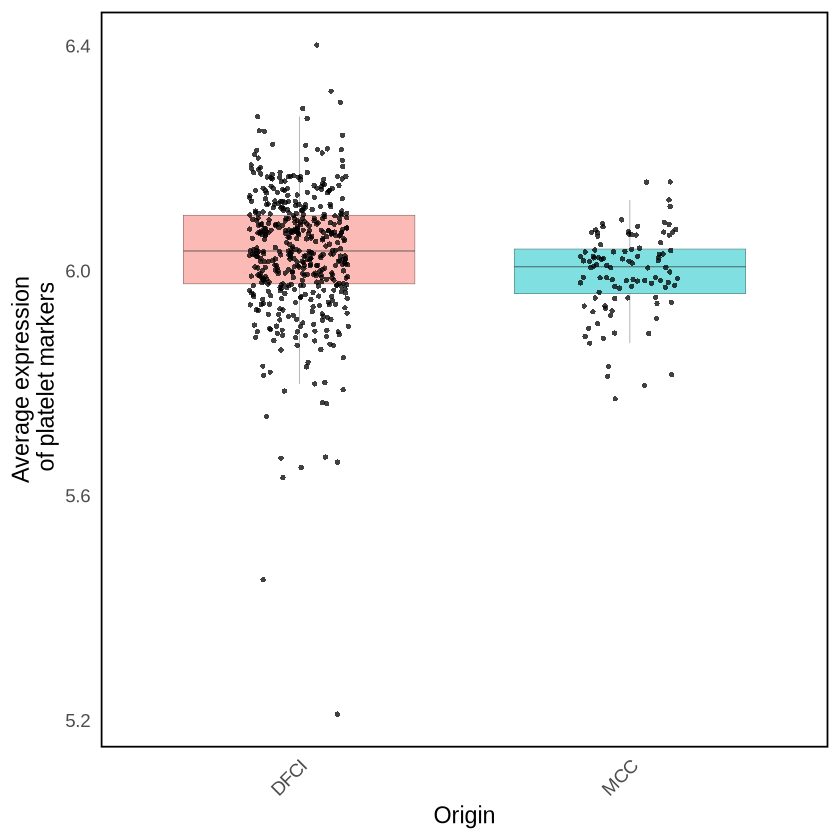

In [ ]:
cor_plt<-ggplot(meta, aes(x = ORIGIN, y = platelet_score, fill = ORIGIN)) +
geom_boxplot(outlier.shape = NA, position = position_dodge(width = 0.8), width = 0.7, alpha = 0.5, size = 0.1) +

  geom_point(size = 1.5, alpha = 0.75, stroke=NA,
            position =  position_jitterdodge(jitter.height=0, 
                                              jitter.width=.3, 
                                              dodge.width = 0.8, 
                                              seed=42)
              )+
  labs(x = "Origin", y = "Average expression\n of platelet markers", 
       title = "Platelet score across sample origins") +
  theme_minimal(base_size = 14) +
  theme(
    panel.grid = element_blank(),
    axis.text.x = element_text(angle = 45, hjust = 1),
    legend.position = "none",
    plot.title = element_blank(),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1)
  )

print(cor_plt)
